# Dataset Provenance and Scientific Context

The CRCNS PVC-2 dataset used in this notebook contains extracellular spike recordings from neurons in the **primary visual cortex (V1) of anesthetized cats**, collected in the laboratory of **Yang Dan (UC Berkeley)**. These recordings were used in influential studies on how cortical neurons encode visual stimuli.

Two key publications based on this dataset are:

#### 1. Touryan, Lau & Dan (2002) — *Isolation of relevant visual features from random stimuli for cortical complex cells*  
**Journal of Neuroscience, 22, 10811–10818**

This study used random stimulus ensembles and spike-triggered covariance methods to identify the stimulus features that drive **complex cells** in V1. It demonstrated that nonlinear receptive field components of cortical neurons can be recovered directly from spike responses.

#### 2. Touryan, Felsen & Dan (2005) — *Spatial Structure of Complex Cell Receptive Fields Measured with Natural Images*  
**Neuron, 45, 781–791**

This later work extended the analysis to **natural image stimuli**, showing that complex-cell receptive fields can be described by a small number of oriented subunits. The results supported the classical **energy model** of visual cortical processing and provided an early example of nonlinear neural encoding under naturalistic stimulation.

## structure of the dataset
Based on archived correspondence from the original investigators, filenames encode:

YYMMDD.(chamber).(penetration)(cell number)(run number)(stimulus).(filetype)

Thus files such as `000413.b03bmsq1D.sa0`, `000413.b03cmsq1D.sa0`, and `000413.b03dmsq1D.sa0` correspond to the same recorded unit (`b03`) across different sequential runs (`b`, `c`, `d`) using the `msq1D` stimulus.

For the `msq1D` white-noise experiments, the `.log` field `StiW` specifies the stimulus width on the display in centimeters. The viewing distance was 114 cm, so 1 cm corresponds to approximately 0.5° of visual angle. Since the stimulus contains 16 bars, the spatial width of each bar is `StiW / 16` cm (≈ `0.5 * StiW / 16` degrees). The stimulus coordinate system was aligned to each neuron's preferred orientation and direction.

- imsq1D.mat = temporal sequence of bar patterns

From the dataset documentation:

msq1D.mat = 1D M-sequence stimulus with 16 bars, 32767 frames
imsq1D.mat = inverted M-sequence stimulus with 512 frames

# settings for the project

In [111]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat
import os
import matplotlib.pyplot as plt
import sys

In [112]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))


DATA_ROOT=PROJECT_ROOT/'data'/'crcns-pvc2'
root =DATA_ROOT / "1D_white_noise/Spike_and_Log_Files"



from src.get_spikes import (fget_spk_python, retrieve_log, tori,
                            load_log_lines, numbers,
                            search_log)

from src.utiles import (is_it_complex, compute_sta, 
                        compute_r_estimate, gaussian_rate_convolution)

In [113]:
from scipy.ndimage import gaussian_filter1d




def bin_spikes_to_frames(spike_times_sec, T, frame_rate, stim_onset_sec=0.0):
    spk_stim_sec = spike_times_sec - stim_onset_sec
    edges = np.arange(T + 1) / frame_rate
    counts, _ = np.histogram(spk_stim_sec, bins=edges)
    return counts


def smooth_frame_counts(counts, frame_rate, sigma_sec=0.05):
    sigma_frames = sigma_sec * frame_rate
    return gaussian_filter1d(
        counts.astype(float),
        sigma=sigma_frames,
        mode="constant"
    ) * frame_rate



def shuffle_test(r_est, rate_test, n_shuffle=500, seed=0):
    rng = np.random.default_rng(seed)

    r_est = np.asarray(r_est)
    rate_test = np.asarray(rate_test)

    valid = np.isfinite(r_est) & np.isfinite(rate_test)

    x = r_est[valid]
    y = rate_test[valid]

    real_corr = np.corrcoef(x, y)[0, 1]

    shuf_corrs = []

    for _ in range(n_shuffle):
        shift = rng.integers(1, len(rate_test))  # avoid zero shift

        rate_shuf = np.roll(rate_test, shift)

        # Re-apply the same valid mask after shuffling
        y_shuf = rate_shuf[valid]

        shuf_corr = np.corrcoef(x, y_shuf)[0, 1]
        shuf_corrs.append(shuf_corr)

    shuf_corrs = np.array(shuf_corrs)

    # one-sided p-value with +1 correction
    p_value = (1 + np.sum(shuf_corrs >= real_corr)) / (n_shuffle + 1)

    return real_corr, shuf_corrs, p_value

In [114]:
cell_results = is_it_complex(root, plot=False)
simple_cells = {
    folder: result
    for folder, result in cell_results.items()
    if result["cell_type"] == "simple / linear-like"
}
simple_cells


Correcting spike file: 000512.d11atune.sa0 -> 000513.d11atune.sa0
Correcting spike file: 000802.c05atune.sa1 -> 000802.c05atune.sa0


{'000420.b02': {'file': '000420.b02atune.log',
  'relmod': 1.8052012990662298,
  'cell_type': 'simple / linear-like'},
 '010801.A.b01': {'file': '010801.A.b01dtune.log',
  'relmod': 1.1081355156101484,
  'cell_type': 'simple / linear-like'}}

In [115]:
COMPLEX_NEURON_PATH= root/'000413.b03'

LINEAR_NEURON_PATH=root/'000420.b02'

STIM_PATH  = DATA_ROOT/'1D_white_noise/Stimulus_Files/msq1D.mat'

ISTIM_PATH = DATA_ROOT/'1D_white_noise/Stimulus_Files/imsq1D.mat'


filenames_complex = [
    
    '000413.b03bmsq1D.sa0',
    '000413.b03cmsq1D.sa0',
    '000413.b03dmsq1D.sa0',
    '000413.b03fmsq1D.sa0',
    '000413.b03hmsq1D.sa0',
]


filenames_linear=[
    '000420.b02bmsq1d.sa0',
    '000420.b02cmsq1d.sa0',
    '000420.b02dmsq1d.sa0',
    '000420.b02emsq1d.sa0',
    '000420.b02fmsq1d.sa0',
    '000420.b02gmsq1d.sa0',
    '000420.b02hmsq1d.sa0'

]


paths_comples_trials = [COMPLEX_NEURON_PATH / name for name in filenames_complex]
paths_linear_trial = [LINEAR_NEURON_PATH / name for name in filenames_linear]

the tuning curves where used to find the prefered direction of the neuron, to which the stimulus are then oriented 

### neuron b03 of 2000

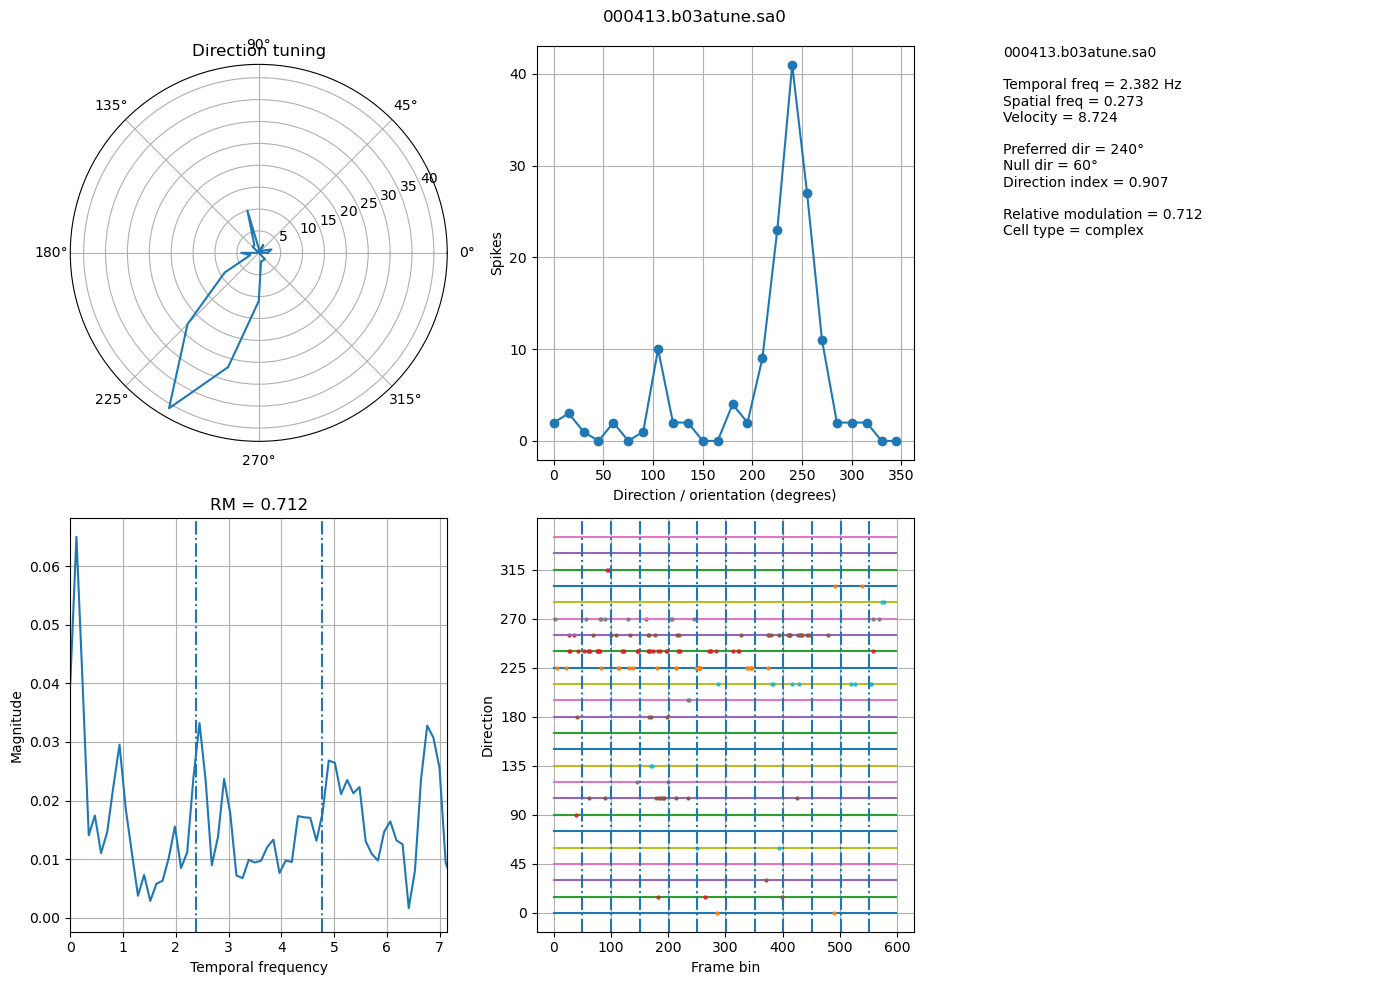

In [116]:
flog = retrieve_log(
    path=COMPLEX_NEURON_PATH,
    filename="000413.b03atune.log",
    channels=None
)

info = tori(flog, cluster_index=0, plot=True)




In [117]:

for path in paths_comples_trials:




    log_lines         = load_log_lines(path)
    remote_rr         = float(numbers(search_log(log_lines, 'TestInfo',  'RemoteRefreshRate', '119.44'))[0])
    frame_rate_factor = float(numbers(search_log(log_lines, 'TestInfo',  'FrameRateFactor',   '2'))[0])
    sti_w             = float(numbers(search_log(log_lines, 'Stimulus',  'StiW',              '9.0'))[0])

    frame_rate = remote_rr / frame_rate_factor    # effective stimulus update rate, ~59.72 Hz
    sti_w_deg  = sti_w * 0.5                      # cm → degrees (1 cm ≈ 0.5° at 114 cm viewing)


    
    print(f'Effective frame rate: {frame_rate:.4f} Hz')
    print(f'Stimulus width: {sti_w} cm = {sti_w_deg:.2f}°  ({sti_w_deg / 16:.3f}°/bar)')

Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)


### neuron b02 of 2004

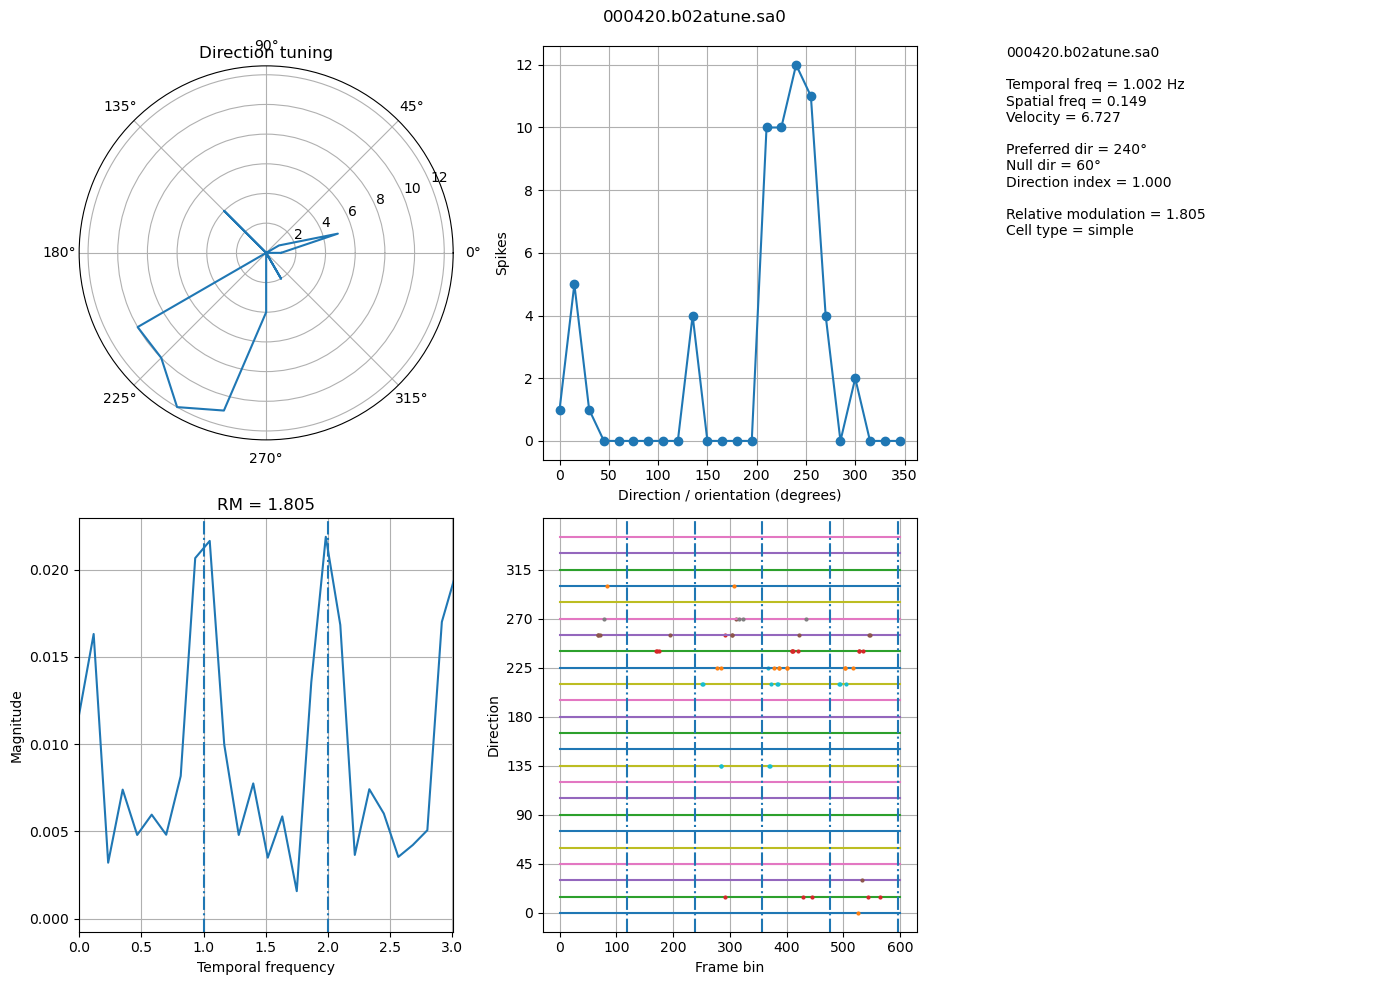

In [118]:
flog = retrieve_log(
    path=LINEAR_NEURON_PATH,
    filename="000420.b02atune.log",
    channels=None
)

info = tori(flog, cluster_index=0, plot=True)
paths = [LINEAR_NEURON_PATH / name for name in filenames_complex]


msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1




In [119]:
for path in paths_linear_trial:


    msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1


    log_lines         = load_log_lines( path)
    remote_rr         = float(numbers(search_log(log_lines, 'TestInfo',  'RemoteRefreshRate', '119.44'))[0])
    frame_rate_factor = float(numbers(search_log(log_lines, 'TestInfo',  'FrameRateFactor',   '2'))[0])
    sti_w             = float(numbers(search_log(log_lines, 'Stimulus',  'StiW',              '9.0'))[0])

    frame_rate = remote_rr / frame_rate_factor    # effective stimulus update rate, ~59.72 Hz
    sti_w_deg  = sti_w * 0.5                      # cm → degrees (1 cm ≈ 0.5° at 114 cm viewing)


    
    print(f'Effective frame rate: {frame_rate:.4f} Hz')
    print(f'Stimulus width: {sti_w} cm = {sti_w_deg:.2f}°  ({sti_w_deg / 16:.3f}°/bar)')

Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)


# stimulus 

- Each column in the left image contains the 16 bars shown at one instant in time, that is, at one stimulus frame. Since the frame rate is approximately 59.72 Hz, each frame lasts about 1/59.72≈0.0167 s, or 16.7 ms. 

- in the right image we can see the stimulus value for one frame 

- the bars are oriented in the preferred direction of the neuron found through the tuning curve

- the value of the bars is -1(dark), +1(bright)



stimulus shape:(32767, 16), stimulus mean=3.051850947599719e-05, stimulus varianc=0.9999999990686206


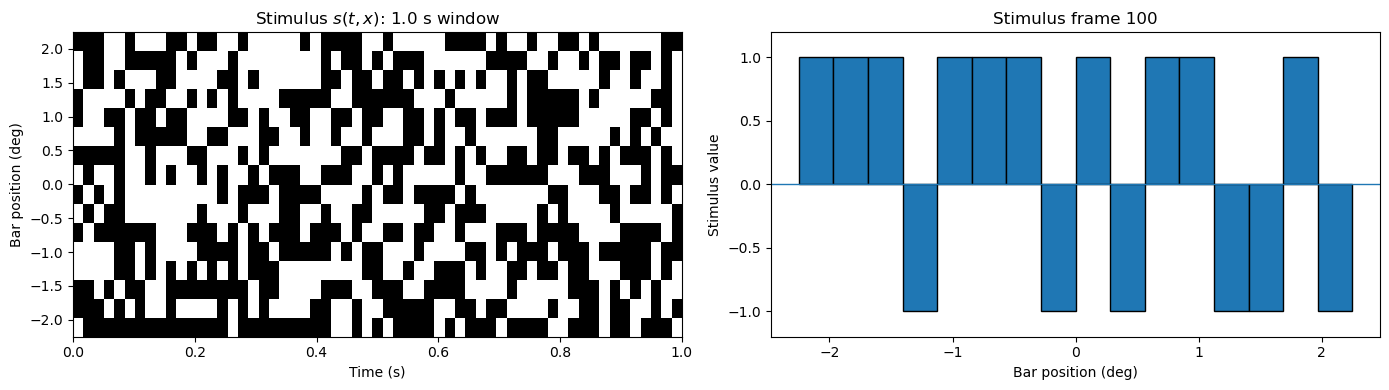

In [120]:
msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1
T, N = msq1D_stim.shape
mean_stim=msq1D_stim.mean()
stimulus_variance=np.var(msq1D_stim)

print(f'stimulus shape:{T,N}, stimulus mean={mean_stim}, stimulus varianc={stimulus_variance}')

T, N = msq1D_stim.shape

width_deg = 4.50
bar_width_deg = width_deg / N

bar_centers = (
    -width_deg / 2
    + bar_width_deg / 2
    + np.arange(N) * bar_width_deg
)


t0 = 0.0
duration = 1.0

i0 = int(t0 * frame_rate)
i1 = int((t0 + duration) * frame_rate)

stim_window = msq1D_stim[i0:i1]

# ---- right plot: one single frame ----
frame = 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: stimulus over time
im = axes[0].imshow(
    stim_window.T,
    aspect="auto",
    cmap="gray",
    interpolation="nearest",
    vmin=-1,
    vmax=1,
    extent=[
        t0,
        t0 + duration,
        -width_deg / 2,
        width_deg / 2,
    ],
    origin="lower"
)

axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Bar position (deg)")
axes[0].set_title(f"Stimulus $s(t,x)$: {duration:.1f} s window")

axes[1].bar(
    bar_centers,
    msq1D_stim[frame],
    width=bar_width_deg,
    align="center",
    edgecolor="black"
)

axes[1].axhline(0, linewidth=1)
axes[1].set_xlabel("Bar position (deg)")
axes[1].set_ylabel("Stimulus value")
axes[1].set_title(f"Stimulus frame {frame}")
axes[1].set_ylim(-1.2, 1.2)


plt.tight_layout()
plt.show()



# simple cell

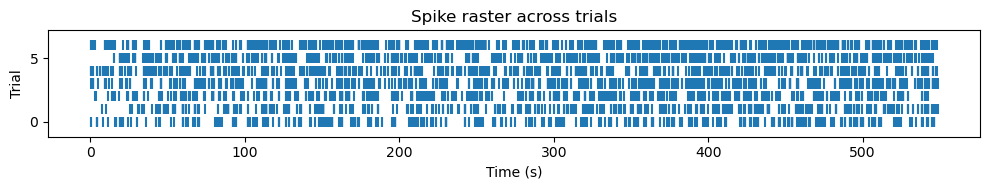

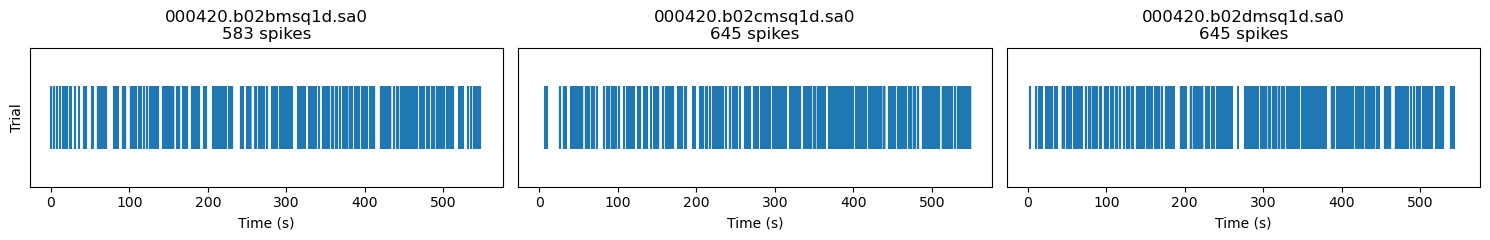

In [121]:
plt.figure(figsize=(10, 2))

for i, path in enumerate(paths_linear_trial):
    events, spk_sec, hdr = fget_spk_python(path)
    plt.eventplot(spk_sec, lineoffsets=i, linelengths=0.8)

plt.xlabel("Time (s)")
plt.ylabel("Trial")
plt.title("Spike raster across trials")
plt.tight_layout()
plt.show()

n_trials = 3

fig, axes = plt.subplots(
    1, n_trials,
    figsize=(5 * n_trials, 2.5),
    sharex=True,
    sharey=True
)

for ax, path in zip(axes, paths_linear_trial[:n_trials]):
    events, spike_times_sec, hdr = fget_spk_python(path)

   
    ax.eventplot(
        spike_times_sec,
        lineoffsets=1,
        linelengths=0.8
    )

    ax.set_title(f"{Path(path).name}\n{len(events)} spikes")
    ax.set_xlabel("Time (s)")
    ax.set_yticks([])

axes[0].set_ylabel("Trial")

plt.tight_layout()
plt.show()

## Spike-Triggered Average (STA)

The spike-triggered average for visual stimuli is defined as the average over trials of stimuli evaluated at times $t_i − τ$ where $t_i$ for
$i = 1,2,...,n$ are the spike times.



#### how do we choose the lag $\tau$ ? At how many milliseconds before the spike is the STA strongest?

To choose the lag window $\tau$, we first computed the STA using a relatively large number of lags. Then, for each lag, we summarized the strength of the STA across the 16 spatial bars by computing its energy:

$E(\tau) =
\sqrt{
\sum_x \mathrm{STA}(\tau, x)^2
}$

then we plotted the sta computed at different lags to visually inspect the structure 

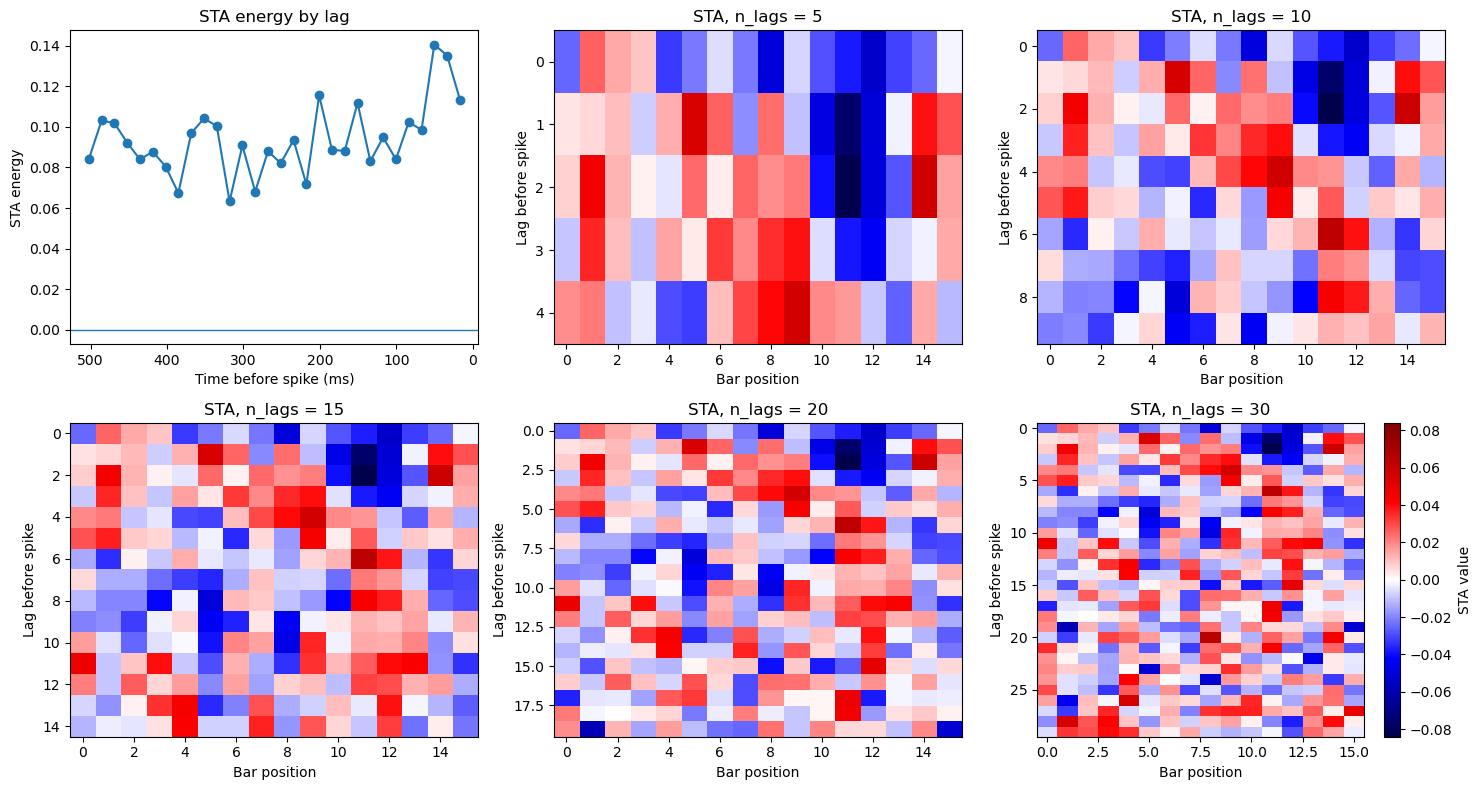

In [ ]:
lag_values = [5, 10, 15, 20, 30]
stas = {}


for L in lag_values:
    sta_L, n_spikes = compute_sta(
        paths_linear_trial,
        msq1D_stim,
        n_lags=L,
        frame_rate=frame_rate
    )
    stas[L] = sta_L

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8),
    sharex=False
)

axes = axes.ravel()


sta_30 = stas[30]
lag_ms = 1000 * np.arange(1, sta_30.shape[0] + 1) / frame_rate
lag_energy = np.sqrt(np.sum(sta_30**2, axis=1))

axes[0].plot(lag_ms, lag_energy, marker="o")
axes[0].invert_xaxis()
axes[0].axhline(0, linewidth=1)
axes[0].set_title("STA energy by lag")
axes[0].set_xlabel("Time before spike (ms)")
axes[0].set_ylabel("STA energy")

# ---------- Remaining five panels: STA heatmaps ----------
vmax = max(np.max(np.abs(stas[L])) for L in lag_values)

for ax, L in zip(axes[1:], lag_values):
    sta_L = stas[L]

    im = ax.imshow(
        sta_L,
        aspect="auto",
        cmap="seismic",
        vmin=-vmax,
        vmax=vmax,
        origin="upper"
    )

    ax.set_title(f"STA, n_lags = {L}")
    ax.set_xlabel("Bar position")
    ax.set_ylabel("Lag before spike")

# ---------- Shared colorbar for heatmaps only ----------
cbar = fig.colorbar(
    im,

)
cbar.set_label("STA value")

plt.tight_layout()
plt.show()

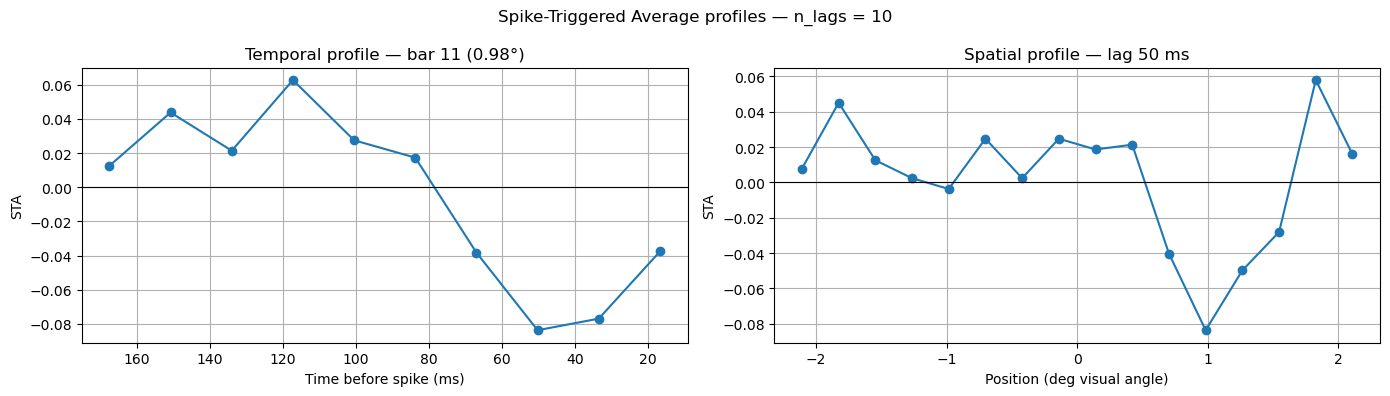

In [134]:
n_lags= 10
sta_plot = stas[n_lags]

lags_ms = np.arange(1, n_lags + 1) / frame_rate * 1000

# Find strongest absolute STA entry
peak_lag, peak_bar = np.unravel_index(
    np.argmax(np.abs(sta_plot)),
    sta_plot.shape
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f"Spike-Triggered Average profiles — n_lags = {n_lags}")

# ---------- Temporal profile at peak spatial position ----------
ax = axes[0]

ax.plot(
    lags_ms,
    sta_plot[:, peak_bar],
    marker="o"
)

ax.axhline(0, color="k", linewidth=0.8)
ax.invert_xaxis()
ax.set_xlabel("Time before spike (ms)")
ax.set_ylabel("STA")
ax.set_title(
    f"Temporal profile — bar {peak_bar} "
    f"({bar_positions[peak_bar]:.2f}°)"
)
ax.grid(True)

# ---------- Spatial profile at peak lag ----------
ax = axes[1]

ax.plot(
    bar_centers,
    sta_plot[peak_lag, :],
    marker="o"
)

ax.axhline(0, color="k", linewidth=0.8)
ax.set_xlabel("Position (deg visual angle)")
ax.set_ylabel("STA")
ax.set_title(
    f"Spatial profile — lag {lags_ms[peak_lag]:.0f} ms"
)
ax.grid(True)

plt.tight_layout()
plt.show()

Since the stimulus frame rate is approximately $59.72 Hz$, one frame corresponds to:


$\frac{1}{59.72} \approx 16.7 \text{ ms}.$

Thus, using $10$ lags corresponds to approximately:


$10 \times 16.7 \approx 167 \text{ ms}$

of stimulus history before the spike. Based on the STA energy plot, this window captures the main part of the response while avoiding unnecessarily long, noisier lag windows.

### split-half correlation
Spike-triggered averaging estimates a neuron’s stimulus-dependent receptive field by averaging the stimulus preceding spikes. To assess whether this estimated receptive field is stable rather than dominated by sampling noise, the data can be split into two independent halves and the resulting estimates compared by correlation. A high split-half correlation indicates reliable structure across repeated measurements, whereas a low correlation suggests that the estimate is noisy, weak, or poorly captured by the assumed linear model.

In [136]:
n_lags=10
rng = np.random.default_rng(0)

n_repeats = 100
split_corrs = []

for _ in range(n_repeats):
    shuffled = list(paths_linear_trial)
    rng.shuffle(shuffled)

    half = len(shuffled) // 2
    trial_a = shuffled[:half]
    trial_b = shuffled[half:]

    sta_a, n_a = compute_sta(
        trial_a,
        msq1D_stim,
        n_lags=n_lags,
        frame_rate=frame_rate
    )

    sta_b, n_b = compute_sta(
        trial_b,
        msq1D_stim,
        n_lags=n_lags,
        frame_rate=frame_rate
    )

    r = np.corrcoef(sta_a.ravel(), sta_b.ravel())[0, 1]
    split_corrs.append(r)

split_corrs = np.array(split_corrs)

split_half_mean = split_corrs.mean()
split_half_std = split_corrs.std()

split_half_mean, split_half_std

(0.6620434534387301, 0.04063408476597095)

### Linearity sanity check of the STA filter
we applied the learned STA kernel to the original M-sequence segment and to its contrast-inverted version. The two predicted responses were perfectly anticorrelated, r=−1, as expected for a linear filter under contrast inversion.

In [137]:
imsq1D = loadmat(ISTIM_PATH)["imsq1D"].astype(float)

print(np.all(imsq1D == -msq1D_stim[:512]))
print(np.mean(imsq1D + msq1D_stim[:512]))

True
0.0


In [138]:
r_inv = compute_r_estimate(imsq1D, stas[10])
r_orig_512 = compute_r_estimate(msq1D_stim[:512], stas[10])

valid = np.isfinite(r_inv) & np.isfinite(r_orig_512)

print(np.corrcoef(r_inv[valid], r_orig_512[valid])[0, 1])

-0.9999999999999999


## Optimal Kernel Estimation

The theoretical relation between the optimal linear kernel and the spike-triggered average is $D(\tau, x) = \frac{\langle r \rangle}{\sigma_s^2} \mathrm{STA}(\tau, x)$

The stimulus variance is $\sigma_s^2 \approx 1.$ Thus, for this stimulus, $D(\tau, x)\approx\langle r \rangle \mathrm{STA}(\tau, x).$

So the optimal kernel has the same spatiotemporal structure as the STA, but it is scaled by the mean firing rate.

In [139]:
recording_duration = T / frame_rate * 6
mean_firing_rate = n_spikes / recording_duration


kernel = mean_firing_rate * stas[10] / stimulus_variance
print(f'STA shape: {stas[10].shape}  (lags × bars)')
print(f'kernel shape:{kernel.shape}')

STA shape: (10, 16)  (lags × bars)
kernel shape:(10, 16)


In [140]:
mean_firing_rate

0.8960946480707215

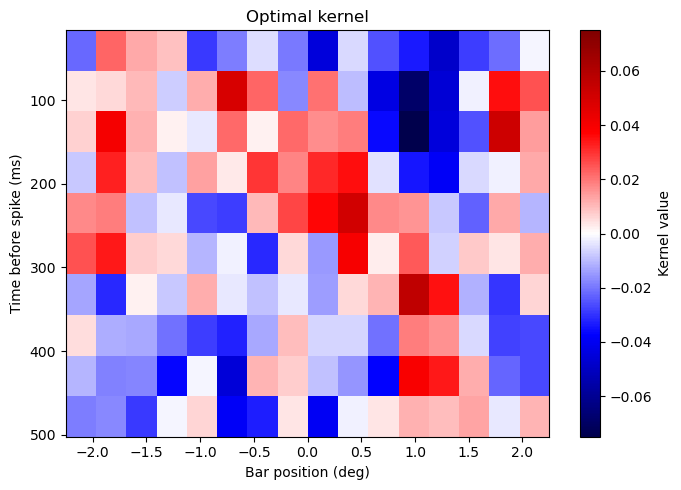

In [141]:
plt.figure(figsize=(7, 5))

vmax = np.max(np.abs(kernel))

plt.imshow(
    kernel,
    aspect="auto",
    cmap="seismic",
    interpolation="nearest",
    vmin=-vmax,
    vmax=vmax,
    extent=[
        -width_deg / 2,
        width_deg / 2,
        lag_ms[-1],
        lag_ms[0],
    ],
    origin="upper"
)

plt.xlabel("Bar position (deg)")
plt.ylabel("Time before spike (ms)")
plt.title("Optimal kernel")
plt.colorbar(label="Kernel value")
plt.tight_layout()
plt.show()

Mean correlation: 0.014247037452531747
Std correlation: 0.004403253490771355


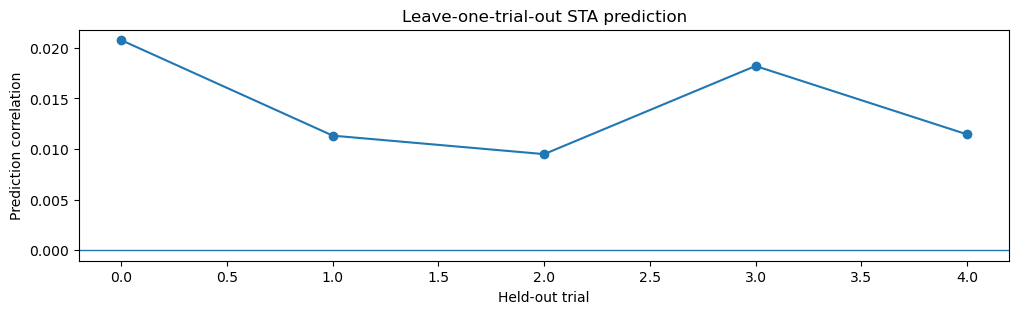

In [ ]:
loo_corrs = []

for test_idx in range(len(paths_linear_trial,)):
    train_files = [f for i, f in enumerate(paths_linear_trial,) if i != test_idx]
    test_file = paths_linear_trial[test_idx]

    sta_train, n_train = compute_sta(
        train_files,
        msq1D_stim,
        n_lags=n_lags,
        frame_rate=frame_rate,
        
    )

    r_est = compute_r_estimate(msq1D_stim, sta_train)

    _, spk_sec_test, _ = fget_spk_python(test_file)

    spike_counts = bin_spikes_to_frames(
        spk_sec_test,
        T=T,
        frame_rate=frame_rate,
        
    )

    rate_test = smooth_frame_counts(
        spike_counts,
        frame_rate=frame_rate,
        sigma_sec=0.05
    )
    valid = np.isfinite(r_est) & np.isfinite(rate_test)
    x = r_est[valid]
    y = rate_test[valid]
    corr=np.corrcoef(x, y)[0, 1]
    
    loo_corrs.append(corr)

loo_corrs = np.array(loo_corrs)

print("Mean correlation:", np.nanmean(loo_corrs))
print("Std correlation:", np.nanstd(loo_corrs))


plt.figure(figsize=(12, 3))
plt.plot(loo_corrs, marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Held-out trial")
plt.ylabel("Prediction correlation")
plt.title("Leave-one-trial-out STA prediction")
plt.show()


Real correlation: 0.011454121922299727
Shuffle mean: -0.0002858484980556328
Shuffle std: 0.006589859409705117
p-value: 0.0499001996007984


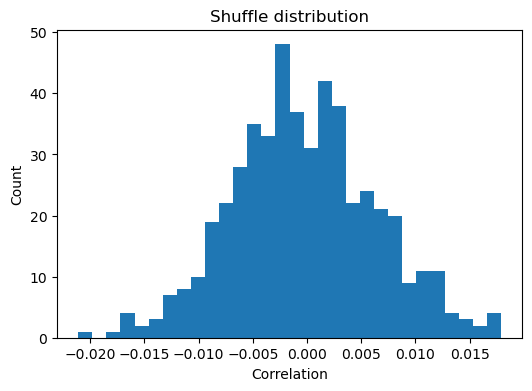

In [145]:

real_corr, shuf_corrs, p_value = shuffle_test(r_est, rate_test, n_shuffle=500)


print("Real correlation:", real_corr)
print("Shuffle mean:", np.nanmean(shuf_corrs))
print("Shuffle std:", np.nanstd(shuf_corrs))
print("p-value:", p_value)




plt.figure(figsize=(6, 4))
plt.hist(shuf_corrs, bins=30)
plt.xlabel("Correlation")
plt.ylabel("Count")
plt.title('Shuffle distribution')
plt.show()